# Sieci neuronowe i Deep Learning
# Temat 5: Moduł torch.nn w bibliotece PyTorch

## Zadanie 5.1

Wykorzystując moduł `torch.nn`, zbudować sieć MLP dla zadania
klasyfikacji odręcznie pisanych cyfr na podstawie zbioru danych MNIST, rozważanego w ramach zajęć nr 3 (patrz notebook do tematu nr 3).

- W pierwszej kolejności odtworzyć sieć implementowaną od podstaw jako przykład w ramach zajęć nr 3 i porównać otrzymane wyniki.

- Następnie rozważyć różne modyfikacje tej sieci z wykorzystaniem możliwości, które daje moduł `torch.nn` (rozważyć inną liczbę i budowę warstw ukrytych, przetestować różne funkcje aktywacji oraz inne algorytmy optymalizacyjne z modułu `torch.optim`). Porównać otrzymane wyniki.

Wszystkie sieci w ramach tego zadania skonstruować na podstawie tych samych danych uczących, walidacyjnych i testowych – utworzonych w analogiczny sposób jak w notebooku z wykładu 3.

In [ ]:
from sklearn.datasets import fetch_openml

import torch.nn.functional as F


X, y = fetch_openml('mnist_784', version=1, return_X_y=True)
X = X.values
y = y.astype(int).values

print(X.shape)
print(y.shape)

# Normalizacja cech do przedziału [-1,1]
# (pod optymalizację metodą gradientową):
X = ((X / 255.) - .5) * 2

from sklearn.model_selection import train_test_split


X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=10000, random_state=123, stratify=y)

X_train, X_valid, y_train, y_valid = train_test_split(
    X_temp, y_temp, test_size=5000, random_state=123, stratify=y_temp)


# optional to free up some memory by deleting non-used arrays:
del X_temp, y_temp, X, y


(70000, 784)
(70000,)


In [ ]:
import torch
from torch.utils.data import TensorDataset
from torch.utils.data import DataLoader



X_train_norm=torch.from_numpy(X_train).float()
y_train=torch.from_numpy(y_train).long()
y_train_onehot = F.one_hot(y_train, num_classes=10)
y_train_onehot = y_train_onehot.float()

train_ds= TensorDataset(X_train_norm,y_train_onehot)

torch.manual_seed(1)
batch_size = 100
train_dl = DataLoader(train_ds, batch_size, shuffle=True)

In [ ]:
import torch
import torch.nn as nn
class Model(nn.Module):

# W metodzie inicjalizacji określamy warstwy sieci:
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()  # Wywołanie konstruktora klasy bazowej nn.Module
                            # (super() jest używane do odwołania się do klasy bazowej)
        self.layer1 = nn.Linear(input_size, hidden_size)
        self.layer2 = nn.Linear(hidden_size, output_size)

# Metoda forward: definiujemy sposób, w jaki dane wejściowe x są przetwarzane przez model:
    def forward(self, x):
        x = self.layer1(x)
        x = nn.Sigmoid()(x)
        x = self.layer2(x)
        x = nn.Sigmoid()(x)
        return x

In [ ]:
input_size = X_train_norm.shape[1]
hidden_size = 50
output_size = 10

model = Model(input_size, hidden_size, output_size)

learning_rate = 0.1

loss_fn = nn.MSELoss()

optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

In [ ]:
# Uczenie modelu (przez 100 epok):

num_epochs = 50
loss_hist = [0] * num_epochs
accuracy_hist = [0] * num_epochs

for epoch in range(num_epochs):

    for x_batch, y_batch in train_dl:
        pred = model(x_batch)  # Predykcja na x_batch
        loss = loss_fn(pred, y_batch)  # Obliczanie funkcji straty między pred a y_batch.long()
                                              # Konwersja .long() jest wymagana przez funkcję straty CrossEntropyLoss
        loss.backward()  # Wsteczna propagacja błędów: oblicza gradienty funkcji straty
        optimizer.step()  # Aktualizuje parametry modelu przy użyciu obliczonych gradientów
        optimizer.zero_grad()  # Zeruje gradienty w optymalizatorze, aby były gotowe do następnej iteracji

        loss_hist[epoch] += loss.item()*y_batch.size(0)
        # Note: If y_batch was one-hot, need to convert it back to class indices for comparison
        # However, for MSELoss with one-hot targets, the argmax of pred is compared with argmax of y_batch
        is_correct = (torch.argmax(pred, dim=1) == torch.argmax(y_batch, dim=1)).float()
        accuracy_hist[epoch] += is_correct.sum()

    loss_hist[epoch] /= len(train_dl.dataset)
    accuracy_hist[epoch] /= len(train_dl.dataset)

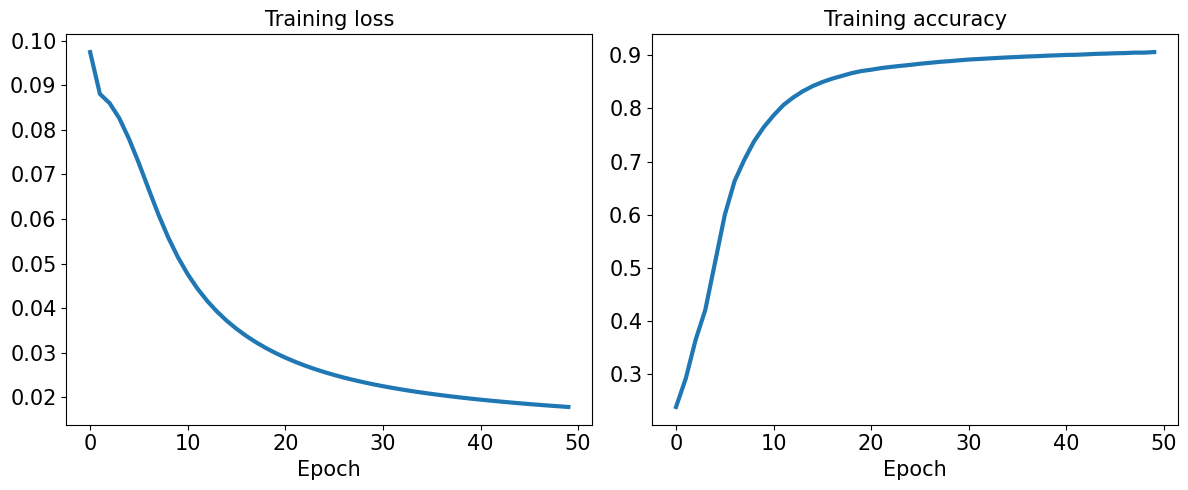

In [ ]:
import matplotlib.pyplot as plt


fig = plt.figure(figsize=(12, 5))
ax = fig.add_subplot(1, 2, 1)
ax.plot(loss_hist, lw=3)
ax.set_title('Training loss', size=15)
ax.set_xlabel('Epoch', size=15)
ax.tick_params(axis='both', which='major', labelsize=15)

ax = fig.add_subplot(1, 2, 2)
ax.plot(accuracy_hist, lw=3)
ax.set_title('Training accuracy', size=15)
ax.set_xlabel('Epoch', size=15)
ax.tick_params(axis='both', which='major', labelsize=15)
plt.tight_layout()


plt.show()

In [ ]:
import torch
import torch.nn as nn
class Model2(nn.Module):

# W metodzie inicjalizacji określamy warstwy sieci:
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()  # Wywołanie konstruktora klasy bazowej nn.Module
                            # (super() jest używane do odwołania się do klasy bazowej)
        self.layer1 = nn.Linear(input_size, hidden_size)
        self.layer2 = nn.Linear(hidden_size, output_size)

# Metoda forward: definiujemy sposób, w jaki dane wejściowe x są przetwarzane przez model:
    def forward(self, x):
        x = self.layer1(x)
        x = nn.Sigmoid()(x)
        x = self.layer2(x)
        x = nn.Softmax(dim=1)(x)  # Będzie wyjaśnione
        return x

In [ ]:
input_size = X_train_norm.shape[1]
hidden_size = 60
output_size = 10

model = Model2(input_size, hidden_size, output_size)

learning_rate = 0.15

loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

In [ ]:
num_epochs = 30
loss_hist = [0] * num_epochs
accuracy_hist = [0] * num_epochs

for epoch in range(num_epochs):

    for x_batch, y_batch in train_dl:
        pred = model(x_batch)  # Predykcja na x_batch
        # Poprawka: nn.CrossEntropyLoss oczekuje indeksów klas (Long), nie one-hot encoding (Float).
        # Konwertujemy one-hot y_batch na indeksy klas.
        loss = loss_fn(pred, torch.argmax(y_batch, dim=1))  # Obliczanie funkcji straty
        loss.backward()  # Wsteczna propagacja błędów: oblicza gradienty funkcji straty
        optimizer.step()  # Aktualizuje parametry modelu przy użyciu obliczonych gradientów
        optimizer.zero_grad()  # Zeruje gradienty w optymalizatorze, aby były gotowe do następnej iteracji

        loss_hist[epoch] += loss.item()*y_batch.size(0)
        # Poprawka: Porównujemy przewidywane klasy z rzeczywistymi indeksami klas.
        is_correct = (torch.argmax(pred, dim=1) == torch.argmax(y_batch, dim=1)).float()
        accuracy_hist[epoch] += is_correct.sum()

    loss_hist[epoch] /= len(train_dl.dataset)
    accuracy_hist[epoch] /= len(train_dl.dataset)

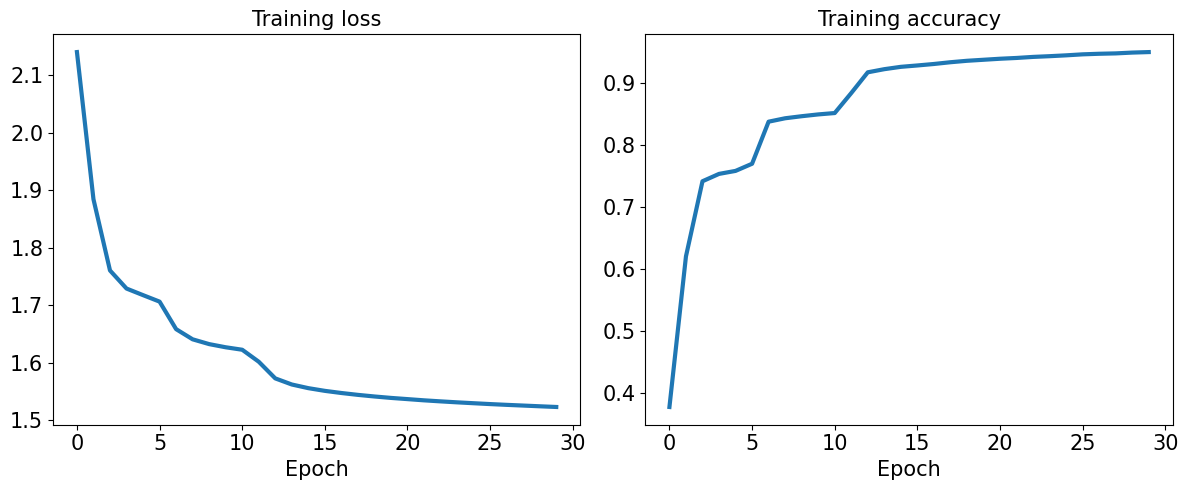

In [ ]:
import matplotlib.pyplot as plt


fig = plt.figure(figsize=(12, 5))
ax = fig.add_subplot(1, 2, 1)
ax.plot(loss_hist, lw=3)
ax.set_title('Training loss', size=15)
ax.set_xlabel('Epoch', size=15)
ax.tick_params(axis='both', which='major', labelsize=15)

ax = fig.add_subplot(1, 2, 2)
ax.plot(accuracy_hist, lw=3)
ax.set_title('Training accuracy', size=15)
ax.set_xlabel('Epoch', size=15)
ax.tick_params(axis='both', which='major', labelsize=15)
plt.tight_layout()


plt.show()